# Synthetic ELISA Immunoassay QC Analysis

**Portfolio project by Donna Cartledge Wolf, PhD**

This notebook demonstrates a reproducible ELISA analysis workflow using Python: data integrity checks, plate-specific 4-parameter logistic (4PL) standard-curve fitting, back-calculation of concentrations, duplicate precision, QC recovery, plate-level acceptance criteria, and investigation of position/read-order effects.

> **Data safety:** All data in this project are fully synthetic and were generated solely for portfolio demonstration. They contain no patient, client, employer, proprietary, confidential, or unpublished experimental data.

### Analytical integrity

The source CSV contains several synthetic ground-truth fields used when the synthetic data were generated. **This notebook intentionally excludes those fields from the analysis.** Concentrations, CVs, recoveries, and QC decisions are recalculated from the raw OD450 values.

Only at the very end do we consult the known synthetic design to test whether the workflow successfully detected the deliberately planted anomalies.

## Analysis workflow

1. Load and verify the 25-plate dataset.
2. Retain only the experimental-style fields needed for analysis.
3. Fit an independent 4PL standard curve to each plate.
4. Back-calculate sample concentrations from OD450.
5. Apply dilution correction to unknown samples.
6. Calculate duplicate CV and QC recovery.
7. Apply illustrative plate-level QC criteria.
8. Investigate standard-position bias and read-order drift.
9. Classify each plate as **Pass**, **Review**, or **Fail**.
10. Validate the resulting anomaly detection against the synthetic design key.

### Illustrative QC criteria

These criteria are intentionally simplified for a portfolio demonstration and are **not a validated regulatory SOP**:

- Mean blank OD ≤ **0.150**
- Standard-curve R² ≥ **0.990**
- QC duplicate CV ≤ **20%**
- QC recovery **80–120%**
- Quantifiable unknown duplicate CV >20%: review
- Illustrative assay range: **20–1800 pg/mL** before dilution correction
- Read-order residual slope > |0.00025 OD/read|: review


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

LLOQ = 20.0
ULOQ = 1800.0

# Portable data loading:
# 1) relative path when notebook is in the GitHub repository,
# 2) root-level path when run from another working directory,
# 3) public GitHub raw URL when opened directly in Google Colab.
candidate_sources = [
    Path("../data/synthetic_elisa_25_plate_data.csv"),
    Path("data/synthetic_elisa_25_plate_data.csv"),
    "https://raw.githubusercontent.com/Donna-Cartledge-Wolf/elisa-immunoassay-data-analytics/main/data/synthetic_elisa_25_plate_data.csv",
]

df_source = None
for source in candidate_sources:
    try:
        if isinstance(source, Path):
            if source.exists():
                df_source = pd.read_csv(source)
                data_source_used = str(source)
                break
        else:
            df_source = pd.read_csv(source)
            data_source_used = source
            break
    except Exception:
        pass

if df_source is None:
    raise FileNotFoundError(
        "Dataset could not be loaded. If running locally, place the notebook in notebooks/ "
        "and keep the CSV in data/. If running in Colab, verify internet access."
    )

print(f"Loaded {len(df_source):,} well-level records from: {data_source_used}")


Loaded 2,400 well-level records from: https://raw.githubusercontent.com/Donna-Cartledge-Wolf/elisa-immunoassay-data-analytics/main/data/synthetic_elisa_25_plate_data.csv


## 1. Exclude creator-only answer-key fields

The raw project file deliberately contains ground-truth and precomputed columns so the synthetic generator can be audited. A real assay analyst would not know those values in advance, so we remove them before doing any analysis.

In [2]:
creator_only_columns = [
    "Synthetic_True_Final_Concentration_pg_mL",
    "Calculated_Assay_Concentration_pg_mL",
    "Calculated_Final_Concentration_pg_mL",
    "Result_Qualifier",
    "Replicate_CV_Pct",
    "Recovery_Pct",
    "Sample_QC_Flag",
]

analysis_columns = [
    "Plate_ID", "Batch_ID", "Run_Date", "Analyst", "Instrument_ID",
    "Read_Order", "Well", "Row", "Column",
    "Sample_ID", "Sample_Type", "Replicate", "Dilution_Factor",
    "Expected_Concentration_pg_mL", "OD450",
]

df = df_source[analysis_columns].copy()
df["Run_Date"] = pd.to_datetime(df["Run_Date"])

print("Creator-only columns excluded:")
for column in creator_only_columns:
    print(" •", column)

df.head(8)


Creator-only columns excluded:
 • Synthetic_True_Final_Concentration_pg_mL
 • Calculated_Assay_Concentration_pg_mL
 • Calculated_Final_Concentration_pg_mL
 • Result_Qualifier
 • Replicate_CV_Pct
 • Recovery_Pct
 • Sample_QC_Flag


,Plate_ID,Batch_ID,Run_Date,Analyst,Instrument_ID,Read_Order,Well,Row,Column,Sample_ID,Sample_Type,Replicate,Dilution_Factor,Expected_Concentration_pg_mL,OD450
0,PLT-001,BATCH-01,2026-01-05,Analyst_A,ELISA_Reader_01,1,A1,A,1,STD_2000,Standard,1,1,2000.0,2.26420
1,PLT-001,BATCH-01,2026-01-05,Analyst_A,ELISA_Reader_01,2,A2,A,2,STD_2000,Standard,2,1,2000.0,2.28227
2,PLT-001,BATCH-01,2026-01-05,Analyst_A,ELISA_Reader_01,3,A3,A,3,BLANK,Blank,1,1,0.0,0.04269
3,PLT-001,BATCH-01,2026-01-05,Analyst_A,ELISA_Reader_01,4,A4,A,4,BLANK,Blank,2,1,0.0,0.04364
4,PLT-001,BATCH-01,2026-01-05,Analyst_A,ELISA_Reader_01,5,A5,A,5,SMP-0001,Unknown,1,2,NaN,0.26485
5,PLT-001,BATCH-01,2026-01-05,Analyst_A,ELISA_Reader_01,6,A6,A,6,SMP-0001,Unknown,2,2,NaN,0.25765
6,PLT-001,BATCH-01,2026-01-05,Analyst_A,ELISA_Reader_01,7,A7,A,7,SMP-0002,Unknown,1,1,NaN,0.40607
7,PLT-001,BATCH-01,2026-01-05,Analyst_A,ELISA_Reader_01,8,A8,A,8,SMP-0002,Unknown,2,1,NaN,0.42298


## 2. Data-integrity checks

In [3]:
integrity = pd.Series({
    "Total well records": len(df),
    "Unique plates": df["Plate_ID"].nunique(),
    "Minimum wells per plate": df.groupby("Plate_ID").size().min(),
    "Maximum wells per plate": df.groupby("Plate_ID").size().max(),
    "Unique analysts": df["Analyst"].nunique(),
    "Unique instruments": df["Instrument_ID"].nunique(),
    "Missing OD450 values": int(df["OD450"].isna().sum()),
})

display(integrity.to_frame("Value"))

sample_type_counts = (
    df.groupby(["Plate_ID", "Sample_Type"])
      .size()
      .unstack(fill_value=0)
)

print("\nPer-plate sample-type counts (first five plates):")
display(sample_type_counts.head())

assert df["Plate_ID"].nunique() == 25
assert df.groupby("Plate_ID").size().eq(96).all()
assert df["OD450"].notna().all()
print("✓ Core integrity checks passed.")


,Value
Total well records,2400
Unique plates,25
Minimum wells per plate,96
Maximum wells per plate,96
Unique analysts,3
Unique instruments,2
Missing OD450 values,0



Per-plate sample-type counts (first five plates):


Sample_Type,Blank,QC,Standard,Unknown
Plate_ID,,,,
PLT-001,2,6,16,72
PLT-002,2,6,16,72
PLT-003,2,6,16,72
PLT-004,2,6,16,72
PLT-005,2,6,16,72


✓ Core integrity checks passed.


## 3. Fit a 4-parameter logistic (4PL) standard curve to each plate

For concentration \(x\), the model used here is:

\[
y = Bottom + \frac{Top-Bottom}{1+(EC50/x)^{Hill}}
\]

Each plate is fit independently using only its standard wells. Duplicate standards are retained as separate observations rather than averaged before fitting.

In [4]:
def four_pl(x, bottom, top, ec50, hill):
    x = np.asarray(x, dtype=float)
    safe_x = np.clip(x, 1e-12, None)
    return bottom + (top - bottom) / (1.0 + (ec50 / safe_x) ** hill)


def inverse_four_pl(y, bottom, top, ec50, hill):
    """Back-calculate concentration from OD using a fitted increasing 4PL."""
    y = np.asarray(y, dtype=float)
    eps = 1e-9
    clipped_y = np.clip(y, bottom + eps, top - eps)
    ratio = (top - bottom) / (clipped_y - bottom) - 1.0
    return ec50 / np.power(ratio, 1.0 / hill)


fit_records = []

for plate_id, plate in df.groupby("Plate_ID"):
    standards = plate.loc[plate["Sample_Type"] == "Standard"].copy()
    x = standards["Expected_Concentration_pg_mL"].astype(float).to_numpy()
    y = standards["OD450"].astype(float).to_numpy()

    p0 = [max(0.0, y.min() * 0.8), y.max() * 1.05, 300.0, 1.2]
    bounds = ([0.0, 0.5, 1.0, 0.2], [1.0, 5.0, 5000.0, 5.0])

    popt, pcov = curve_fit(
        four_pl, x, y,
        p0=p0,
        bounds=bounds,
        maxfev=50000
    )

    predicted = four_pl(x, *popt)
    ss_res = np.sum((y - predicted) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot

    fit_records.append({
        "Plate_ID": plate_id,
        "Bottom_OD": popt[0],
        "Top_OD": popt[1],
        "EC50_pg_mL": popt[2],
        "Hill_Slope": popt[3],
        "R2": r2,
    })

fit_df = pd.DataFrame(fit_records).sort_values("Plate_ID").reset_index(drop=True)

display(
    fit_df.style.format({
        "Bottom_OD": "{:.4f}",
        "Top_OD": "{:.4f}",
        "EC50_pg_mL": "{:.1f}",
        "Hill_Slope": "{:.3f}",
        "R2": "{:.5f}",
    })
)


,Plate_ID,Bottom_OD,Top_OD,EC50_pg_mL,Hill_Slope,R2
0,PLT-001,0.0334,2.5068,296.5,1.177,0.99993
1,PLT-002,0.0550,2.3936,300.6,1.278,0.99987
2,PLT-003,0.0333,2.5698,299.4,1.148,0.99969
3,PLT-004,0.0392,2.5201,289.9,1.176,0.99972
4,PLT-005,0.0579,2.5450,305.5,1.242,0.99972
5,PLT-006,0.0519,2.4507,295.6,1.257,0.99969
6,PLT-007,0.1669,2.5590,285.6,1.225,0.99981
7,PLT-008,0.0554,2.3960,299.1,1.228,0.99984
8,PLT-009,0.0595,2.3794,293.0,1.294,0.99976
9,PLT-010,0.0407,2.4930,305.9,1.260,0.99983


### Representative standard curves

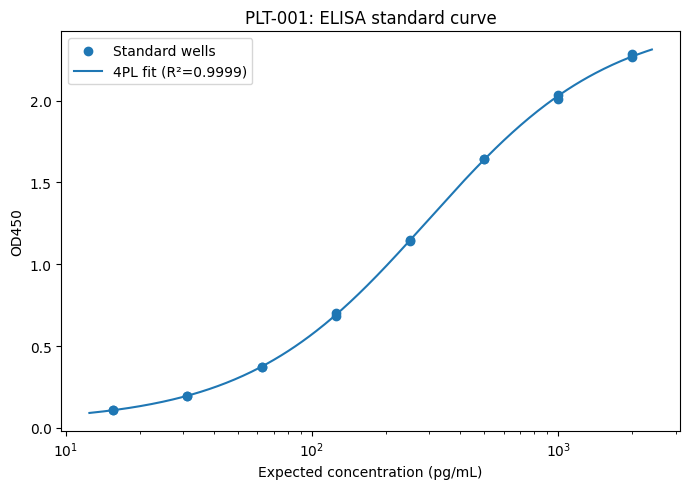

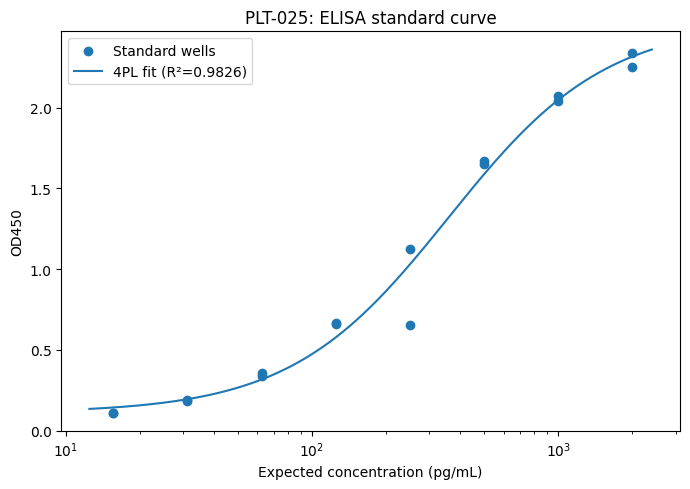

In [5]:
def plot_standard_curve(plate_id):
    plate = df[df["Plate_ID"] == plate_id]
    standards = plate[plate["Sample_Type"] == "Standard"].copy()
    fit = fit_df.loc[fit_df["Plate_ID"] == plate_id].iloc[0]

    x = standards["Expected_Concentration_pg_mL"].astype(float).to_numpy()
    y = standards["OD450"].astype(float).to_numpy()
    x_grid = np.logspace(np.log10(x.min() * 0.8), np.log10(x.max() * 1.2), 400)

    plt.figure(figsize=(7, 5))
    plt.scatter(x, y, label="Standard wells")
    plt.plot(
        x_grid,
        four_pl(x_grid, fit["Bottom_OD"], fit["Top_OD"], fit["EC50_pg_mL"], fit["Hill_Slope"]),
        label=f"4PL fit (R²={fit['R2']:.4f})"
    )
    plt.xscale("log")
    plt.xlabel("Expected concentration (pg/mL)")
    plt.ylabel("OD450")
    plt.title(f"{plate_id}: ELISA standard curve")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_standard_curve("PLT-001")
plot_standard_curve("PLT-025")


PLT-001 is representative of a well-behaved curve. PLT-025 is included for comparison because its standard-curve fit is visibly less consistent.

## 4. Back-calculate concentrations from OD450

The fitted curve for each plate is now used to estimate assay concentration. Unknown samples are then corrected for their dilution factor.

Blank wells are not assigned concentrations; they are evaluated directly by OD450.

In [6]:
results_parts = []

for plate_id, plate in df.groupby("Plate_ID"):
    plate = plate.copy()
    fit = fit_df.loc[fit_df["Plate_ID"] == plate_id].iloc[0]
    params = (fit["Bottom_OD"], fit["Top_OD"], fit["EC50_pg_mL"], fit["Hill_Slope"])

    nonblank = plate["Sample_Type"] != "Blank"
    plate["Analysis_Assay_Concentration_pg_mL"] = np.nan
    plate.loc[nonblank, "Analysis_Assay_Concentration_pg_mL"] = inverse_four_pl(
        plate.loc[nonblank, "OD450"].to_numpy(),
        *params
    )

    dilution = plate["Dilution_Factor"].fillna(1).astype(float)
    plate["Analysis_Final_Concentration_pg_mL"] = (
        plate["Analysis_Assay_Concentration_pg_mL"] * dilution
    )

    plate["Analysis_Result_Qualifier"] = "N/A"
    unknown = plate["Sample_Type"] == "Unknown"
    plate.loc[
        unknown & (plate["Analysis_Assay_Concentration_pg_mL"] < LLOQ),
        "Analysis_Result_Qualifier"
    ] = "<LLOQ"
    plate.loc[
        unknown & (plate["Analysis_Assay_Concentration_pg_mL"].between(LLOQ, ULOQ, inclusive="both")),
        "Analysis_Result_Qualifier"
    ] = "Quantifiable"
    plate.loc[
        unknown & (plate["Analysis_Assay_Concentration_pg_mL"] > ULOQ),
        "Analysis_Result_Qualifier"
    ] = ">ULOQ"

    results_parts.append(plate)

results = pd.concat(results_parts, ignore_index=True)

unknown_qualifiers = (
    results.loc[results["Sample_Type"] == "Unknown", "Analysis_Result_Qualifier"]
           .value_counts()
           .rename_axis("Qualifier")
           .to_frame("Well count")
)

display(unknown_qualifiers)


,Well count
Qualifier,
Quantifiable,1208
<LLOQ,542
>ULOQ,50


## 5. Duplicate precision and QC recovery

In [7]:
group_cols = ["Plate_ID", "Sample_ID", "Sample_Type"]

sample_metrics = (
    results.groupby(group_cols, as_index=False)
           .agg(
               Mean_Calculated_Final_Concentration_pg_mL=("Analysis_Final_Concentration_pg_mL", "mean"),
               SD_Calculated_Final_Concentration_pg_mL=("Analysis_Final_Concentration_pg_mL", "std"),
               Expected_Concentration_pg_mL=("Expected_Concentration_pg_mL", "first"),
               N=("Replicate", "count"),
               All_Replicates_Quantifiable=(
    "Analysis_Result_Qualifier",
    lambda x: (x == "Quantifiable").all()
),
           )
)

sample_metrics["Replicate_CV_Pct"] = (
    sample_metrics["SD_Calculated_Final_Concentration_pg_mL"]
    / sample_metrics["Mean_Calculated_Final_Concentration_pg_mL"]
    * 100.0
)

sample_metrics["Recovery_Pct"] = (
    sample_metrics["Mean_Calculated_Final_Concentration_pg_mL"]
    / sample_metrics["Expected_Concentration_pg_mL"]
    * 100.0
)

qc_metrics = sample_metrics[sample_metrics["Sample_Type"] == "QC"].copy()

display(
    qc_metrics.head(12).style.format({
        "Mean_Calculated_Final_Concentration_pg_mL": "{:.1f}",
        "SD_Calculated_Final_Concentration_pg_mL": "{:.1f}",
        "Expected_Concentration_pg_mL": "{:.1f}",
        "Replicate_CV_Pct": "{:.2f}",
        "Recovery_Pct": "{:.1f}",
    })
)


,Plate_ID,Sample_ID,Sample_Type,Mean_Calculated_Final_Concentration_pg_mL,SD_Calculated_Final_Concentration_pg_mL,Expected_Concentration_pg_mL,N,All_Replicates_Quantifiable,Replicate_CV_Pct,Recovery_Pct
1,PLT-001,QC_High,QC,1218.8,18.9,1200.0,2,False,1.55,101.6
2,PLT-001,QC_Low,QC,50.2,0.8,50.0,2,False,1.63,100.4
3,PLT-001,QC_Mid,QC,299.0,6.0,300.0,2,False,2.00,99.7
49,PLT-002,QC_High,QC,1194.3,76.4,1200.0,2,False,6.40,99.5
50,PLT-002,QC_Low,QC,50.0,0.3,50.0,2,False,0.62,100.1
51,PLT-002,QC_Mid,QC,298.9,14.8,300.0,2,False,4.95,99.6
97,PLT-003,QC_High,QC,1258.1,127.9,1200.0,2,False,10.17,104.8
98,PLT-003,QC_Low,QC,49.2,0.6,50.0,2,False,1.21,98.4
99,PLT-003,QC_Mid,QC,302.6,5.2,300.0,2,False,1.73,100.9
145,PLT-004,QC_High,QC,1150.1,62.2,1200.0,2,False,5.41,95.8


### QC recovery across plates

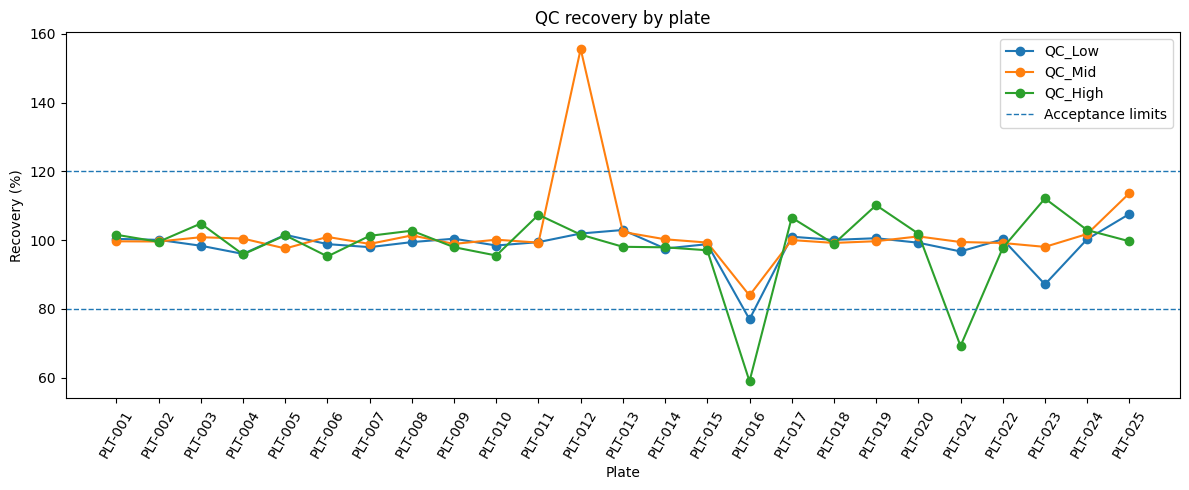

In [8]:
qc_recovery_wide = (
    qc_metrics.pivot(index="Plate_ID", columns="Sample_ID", values="Recovery_Pct")
              .reindex(fit_df["Plate_ID"])
)

plt.figure(figsize=(12, 5))
for qc_name in ["QC_Low", "QC_Mid", "QC_High"]:
    plt.plot(qc_recovery_wide.index, qc_recovery_wide[qc_name], marker="o", label=qc_name)

plt.axhline(80, linestyle="--", linewidth=1, label="Acceptance limits")
plt.axhline(120, linestyle="--", linewidth=1)
plt.xticks(rotation=60)
plt.ylabel("Recovery (%)")
plt.xlabel("Plate")
plt.title("QC recovery by plate")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Plate-level QC metrics

The primary pass/fail decision uses blank background, standard-curve goodness-of-fit, QC duplicate precision, and QC recovery.

In [9]:
plate_qc_records = []

for plate_id, plate in results.groupby("Plate_ID"):
    fit = fit_df.loc[fit_df["Plate_ID"] == plate_id].iloc[0]
    plate_qc = qc_metrics[qc_metrics["Plate_ID"] == plate_id]

    blank_mean = plate.loc[plate["Sample_Type"] == "Blank", "OD450"].mean()
    max_qc_cv = plate_qc["Replicate_CV_Pct"].max()
    min_qc_recovery = plate_qc["Recovery_Pct"].min()
    max_qc_recovery = plate_qc["Recovery_Pct"].max()

    unknown_metrics = sample_metrics[
        (sample_metrics["Plate_ID"] == plate_id) &
        (sample_metrics["Sample_Type"] == "Unknown") &
        (sample_metrics["All_Replicates_Quantifiable"])
    ]
    unknown_review_count = int((unknown_metrics["Replicate_CV_Pct"] > 20).sum())

    plate_qc_records.append({
        "Plate_ID": plate_id,
        "Mean_Blank_OD": blank_mean,
        "R2": fit["R2"],
        "Max_QC_CV_Pct": max_qc_cv,
        "Min_QC_Recovery_Pct": min_qc_recovery,
        "Max_QC_Recovery_Pct": max_qc_recovery,
        "Unknown_Samples_CV_Review_Count": unknown_review_count,
    })

plate_qc = pd.DataFrame(plate_qc_records).sort_values("Plate_ID").reset_index(drop=True)
display(plate_qc.head())


,Plate_ID,Mean_Blank_OD,R2,Max_QC_CV_Pct,Min_QC_Recovery_Pct,Max_QC_Recovery_Pct,Unknown_Samples_CV_Review_Count
0,PLT-001,0.043165,0.999931,1.998176,99.670733,101.570550,0
1,PLT-002,0.051170,0.999872,6.401165,99.522922,100.092157,0
2,PLT-003,0.042305,0.999687,10.165580,98.384478,104.844053,0
3,PLT-004,0.048965,0.999722,5.407122,95.845345,100.468948,0
4,PLT-005,0.052040,0.999724,5.145927,97.585660,101.554097,0


## 7. Layout-aware diagnostic for a possible edge effect

In this synthetic plate layout, the two standard replicates occupy adjacent columns: replicate 1 is in **column 1 (edge)** and replicate 2 in **column 2 (non-edge)**. That gives us a useful within-concentration positional comparison.

For each plate, we calculate the directional percent OD difference between those paired standard wells. A large, consistent positive difference suggests elevated signal at the outer edge rather than random duplicate noise.

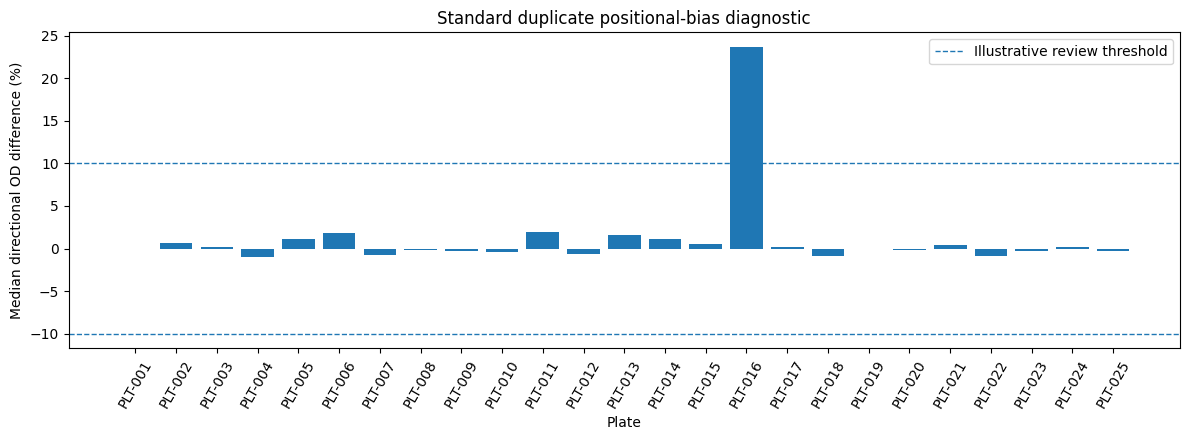

,Plate_ID,Median_Standard_Edge_vs_Interior_OD_Diff_Pct,Max_Absolute_Standard_Duplicate_OD_Diff_Pct
15,PLT-016,23.7,29.1
10,PLT-011,2.0,5.9
5,PLT-006,1.8,7.5
12,PLT-013,1.6,6.2
13,PLT-014,1.1,4.2


In [10]:
edge_records = []

for plate_id, plate in df.groupby("Plate_ID"):
    standards = plate[plate["Sample_Type"] == "Standard"].copy()
    paired = standards.pivot(
        index="Expected_Concentration_pg_mL",
        columns="Replicate",
        values="OD450"
    )

    pct_difference = (paired[1] / paired[2] - 1.0) * 100.0

    edge_records.append({
        "Plate_ID": plate_id,
        "Median_Standard_Edge_vs_Interior_OD_Diff_Pct": pct_difference.median(),
        "Max_Absolute_Standard_Duplicate_OD_Diff_Pct": pct_difference.abs().max(),
    })

edge_diag = pd.DataFrame(edge_records).sort_values("Plate_ID").reset_index(drop=True)

plt.figure(figsize=(12, 4.5))
plt.bar(
    edge_diag["Plate_ID"],
    edge_diag["Median_Standard_Edge_vs_Interior_OD_Diff_Pct"]
)
plt.axhline(10, linestyle="--", linewidth=1, label="Illustrative review threshold")
plt.axhline(-10, linestyle="--", linewidth=1)
plt.xticks(rotation=60)
plt.ylabel("Median directional OD difference (%)")
plt.xlabel("Plate")
plt.title("Standard duplicate positional-bias diagnostic")
plt.legend()
plt.tight_layout()
plt.show()

display(
    edge_diag.sort_values(
        "Median_Standard_Edge_vs_Interior_OD_Diff_Pct",
        ascending=False
    ).head(5).style.format({
        "Median_Standard_Edge_vs_Interior_OD_Diff_Pct": "{:.1f}",
        "Max_Absolute_Standard_Duplicate_OD_Diff_Pct": "{:.1f}",
    })
)


## 8. Read-order drift diagnostic

To avoid confounding read order with unknown sample concentration, this diagnostic uses only wells with known expected concentration: **standards, QCs, and blanks**.

For each known well, we calculate:

**OD residual = observed OD − OD expected from the fitted 4PL**

We then regress those residuals against read order. A consistent positive or negative slope suggests signal drift during plate reading.

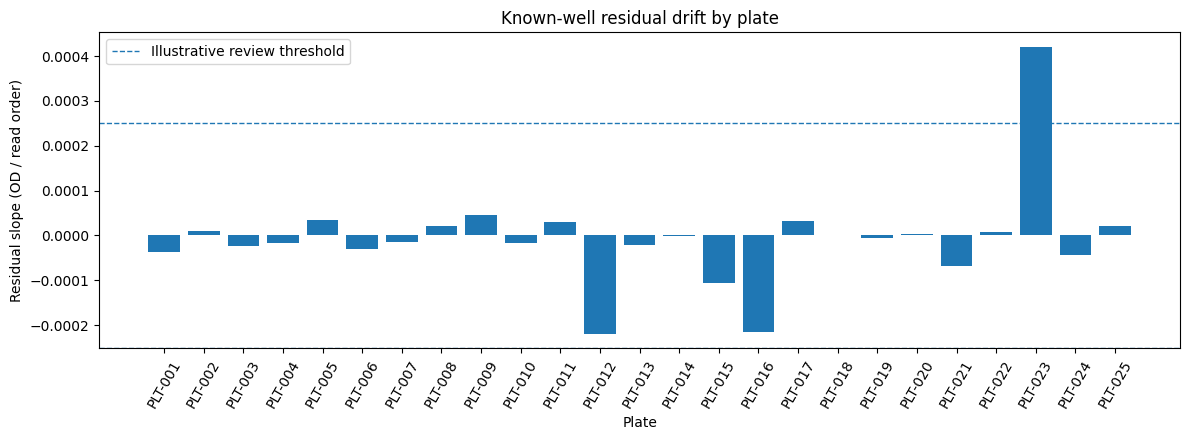

,Plate_ID,Known_Well_Residual_Slope_OD_per_Read
22,PLT-023,0.0004209
11,PLT-012,-0.0002187
15,PLT-016,-0.0002153
14,PLT-015,-0.0001050
20,PLT-021,-0.0000692


In [11]:
drift_records = []

for plate_id, plate in df.groupby("Plate_ID"):
    fit = fit_df.loc[fit_df["Plate_ID"] == plate_id].iloc[0]
    params = (fit["Bottom_OD"], fit["Top_OD"], fit["EC50_pg_mL"], fit["Hill_Slope"])

    known = plate[plate["Sample_Type"].isin(["Standard", "QC", "Blank"])].copy()
    known["Expected_For_Model"] = known["Expected_Concentration_pg_mL"].fillna(0.0)
    known["Expected_OD"] = four_pl(known["Expected_For_Model"].to_numpy(), *params)
    known["OD_Residual"] = known["OD450"] - known["Expected_OD"]

    slope, intercept = np.polyfit(
        known["Read_Order"].astype(float),
        known["OD_Residual"].astype(float),
        1
    )

    drift_records.append({
        "Plate_ID": plate_id,
        "Known_Well_Residual_Slope_OD_per_Read": slope,
    })

drift_diag = pd.DataFrame(drift_records).sort_values("Plate_ID").reset_index(drop=True)

plt.figure(figsize=(12, 4.5))
plt.bar(
    drift_diag["Plate_ID"],
    drift_diag["Known_Well_Residual_Slope_OD_per_Read"]
)
plt.axhline(0.00025, linestyle="--", linewidth=1, label="Illustrative review threshold")
plt.axhline(-0.00025, linestyle="--", linewidth=1)
plt.xticks(rotation=60)
plt.ylabel("Residual slope (OD / read order)")
plt.xlabel("Plate")
plt.title("Known-well residual drift by plate")
plt.legend()
plt.tight_layout()
plt.show()

display(
    drift_diag.reindex(
        drift_diag["Known_Well_Residual_Slope_OD_per_Read"].abs()
                  .sort_values(ascending=False).index
    ).head(5).style.format({
        "Known_Well_Residual_Slope_OD_per_Read": "{:.7f}",
    })
)


## 9. Combine primary QC and diagnostic findings

- **Fail** = at least one primary QC criterion fails.
- **Review** = primary criteria pass, but the read-order drift diagnostic exceeds its review threshold.
- **Pass** = primary criteria pass and no drift review is triggered.

The edge-effect and standard-duplicate diagnostics are retained as explanatory/root-cause signals.

In [12]:
plate_summary = (
    plate_qc
    .merge(edge_diag, on="Plate_ID", how="left")
    .merge(drift_diag, on="Plate_ID", how="left")
)

def classify_plate(row):
    primary_reasons = []

    if row["Mean_Blank_OD"] > 0.150:
        primary_reasons.append("High blank")
    if row["R2"] < 0.990:
        primary_reasons.append("Curve fit")
    if row["Max_QC_CV_Pct"] > 20:
        primary_reasons.append("QC CV")
    if row["Min_QC_Recovery_Pct"] < 80 or row["Max_QC_Recovery_Pct"] > 120:
        primary_reasons.append("QC recovery")

    review_reasons = []
    if abs(row["Known_Well_Residual_Slope_OD_per_Read"]) > 0.00025:
        review_reasons.append("Read-order drift")

    explanatory = []
    if abs(row["Median_Standard_Edge_vs_Interior_OD_Diff_Pct"]) > 10:
        explanatory.append("Position/edge bias")
    if row["Max_Absolute_Standard_Duplicate_OD_Diff_Pct"] > 20:
        explanatory.append("Large standard duplicate discrepancy")

    if primary_reasons:
        status = "Fail"
    elif review_reasons:
        status = "Review"
    else:
        status = "Pass"

    return pd.Series({
        "Plate_Status": status,
        "Primary_QC_Findings": "; ".join(primary_reasons) if primary_reasons else "None",
        "Review_Findings": "; ".join(review_reasons) if review_reasons else "None",
        "Explanatory_Diagnostics": "; ".join(explanatory) if explanatory else "None",
    })

classification = plate_summary.apply(classify_plate, axis=1)
plate_summary = pd.concat([plate_summary, classification], axis=1)

summary_display_cols = [
    "Plate_ID", "Mean_Blank_OD", "R2", "Max_QC_CV_Pct",
    "Min_QC_Recovery_Pct", "Max_QC_Recovery_Pct",
    "Median_Standard_Edge_vs_Interior_OD_Diff_Pct",
    "Known_Well_Residual_Slope_OD_per_Read",
    "Plate_Status", "Primary_QC_Findings", "Review_Findings",
    "Explanatory_Diagnostics",
]

display(
    plate_summary[summary_display_cols].style.format({
        "Mean_Blank_OD": "{:.4f}",
        "R2": "{:.5f}",
        "Max_QC_CV_Pct": "{:.1f}",
        "Min_QC_Recovery_Pct": "{:.1f}",
        "Max_QC_Recovery_Pct": "{:.1f}",
        "Median_Standard_Edge_vs_Interior_OD_Diff_Pct": "{:.1f}",
        "Known_Well_Residual_Slope_OD_per_Read": "{:.7f}",
    })
)

print("\nStatus counts:")
display(plate_summary["Plate_Status"].value_counts().to_frame("Plates"))


,Plate_ID,Mean_Blank_OD,R2,Max_QC_CV_Pct,Min_QC_Recovery_Pct,Max_QC_Recovery_Pct,Median_Standard_Edge_vs_Interior_OD_Diff_Pct,Known_Well_Residual_Slope_OD_per_Read,Plate_Status,Primary_QC_Findings,Review_Findings,Explanatory_Diagnostics
0,PLT-001,0.0432,0.99993,2.0,99.7,101.6,-0.0,-0.0000368,Pass,None,None,None
1,PLT-002,0.0512,0.99987,6.4,99.5,100.1,0.6,0.0000092,Pass,None,None,None
2,PLT-003,0.0423,0.99969,10.2,98.4,104.8,0.2,-0.0000242,Pass,None,None,None
3,PLT-004,0.0490,0.99972,5.4,95.8,100.5,-1.0,-0.0000172,Pass,None,None,None
4,PLT-005,0.0520,0.99972,5.1,97.6,101.6,1.1,0.0000337,Pass,None,None,None
5,PLT-006,0.0543,0.99969,7.5,95.3,100.9,1.8,-0.0000300,Pass,None,None,None
6,PLT-007,0.1761,0.99981,5.1,98.0,101.3,-0.8,-0.0000138,Fail,High blank,None,None
7,PLT-008,0.0497,0.99984,5.1,99.4,102.8,-0.1,0.0000211,Pass,None,None,None
8,PLT-009,0.0479,0.99976,3.5,98.0,100.4,-0.3,0.0000467,Pass,None,None,None
9,PLT-010,0.0458,0.99983,5.1,95.5,100.1,-0.4,-0.0000177,Pass,None,None,None



Status counts:


,Plates
Plate_Status,
Pass,19
Fail,5
Review,1


### Plate status overview

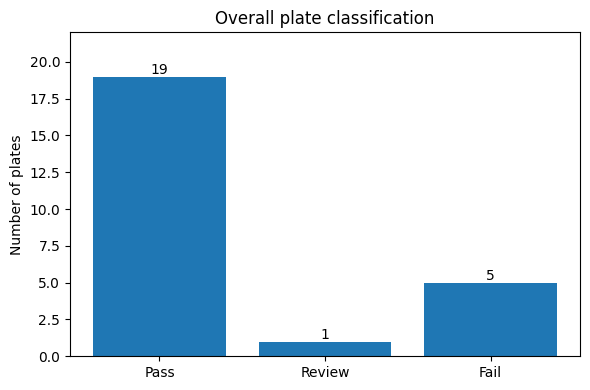

In [13]:
status_counts = (
    plate_summary["Plate_Status"]
    .value_counts()
    .reindex(["Pass", "Review", "Fail"], fill_value=0)
)

plt.figure(figsize=(6, 4))
plt.bar(status_counts.index, status_counts.values)
plt.ylabel("Number of plates")
plt.title("Overall plate classification")
for i, value in enumerate(status_counts.values):
    plt.text(i, value + 0.15, str(value), ha="center")
plt.ylim(0, max(status_counts.values) + 3)
plt.tight_layout()
plt.show()


## 10. Investigate the plates requiring attention

This condensed table is the practical output a laboratory scientist or manager might use to prioritize review.

In [14]:
attention = plate_summary.loc[
    plate_summary["Plate_Status"] != "Pass",
    [
        "Plate_ID", "Plate_Status", "Primary_QC_Findings",
        "Review_Findings", "Explanatory_Diagnostics",
        "Mean_Blank_OD", "R2", "Max_QC_CV_Pct",
        "Min_QC_Recovery_Pct", "Max_QC_Recovery_Pct",
    ]
].copy()

display(
    attention.style.format({
        "Mean_Blank_OD": "{:.4f}",
        "R2": "{:.5f}",
        "Max_QC_CV_Pct": "{:.1f}",
        "Min_QC_Recovery_Pct": "{:.1f}",
        "Max_QC_Recovery_Pct": "{:.1f}",
    })
)


,Plate_ID,Plate_Status,Primary_QC_Findings,Review_Findings,Explanatory_Diagnostics,Mean_Blank_OD,R2,Max_QC_CV_Pct,Min_QC_Recovery_Pct,Max_QC_Recovery_Pct
6,PLT-007,Fail,High blank,None,None,0.1761,0.99981,5.1,98.0,101.3
11,PLT-012,Fail,QC CV; QC recovery,None,None,0.0490,0.99983,52.0,101.6,155.6
15,PLT-016,Fail,Curve fit; QC recovery,None,Position/edge bias; Large standard duplicate discrepancy,0.0647,0.97928,4.2,58.9,83.9
20,PLT-021,Fail,QC recovery,None,None,0.0541,0.99977,1.7,69.2,99.5
22,PLT-023,Review,None,Read-order drift,None,0.0481,0.99955,4.2,87.1,112.1
24,PLT-025,Fail,Curve fit,None,Large standard duplicate discrepancy,0.0472,0.98259,2.7,99.7,113.7


## 11. Synthetic-design validation — consulted only after analysis

At this point the analytical workflow is complete. We can now compare its results with the known synthetic design.

Six plates were deliberately generated with specific problems. This final step tests whether the independent analytical workflow identified them without using the creator-only concentration, CV, recovery, or QC-flag columns.

In [15]:
planted_anomalies = {
    "PLT-007": "High background",
    "PLT-012": "Replicate imprecision",
    "PLT-016": "Edge effect",
    "PLT-021": "Poor high-QC recovery",
    "PLT-023": "Read-order / instrument drift",
    "PLT-025": "Standard-curve outlier",
}

truth = pd.DataFrame(
    [{"Plate_ID": plate, "Planted_Anomaly": issue} for plate, issue in planted_anomalies.items()]
)

validation = truth.merge(
    plate_summary[
        [
            "Plate_ID", "Plate_Status", "Primary_QC_Findings",
            "Review_Findings", "Explanatory_Diagnostics"
        ]
    ],
    on="Plate_ID",
    how="left"
)

validation["Detected"] = validation["Plate_Status"].isin(["Fail", "Review"])

display(validation)

anomaly_detection_rate = validation["Detected"].mean() * 100
routine = plate_summary[~plate_summary["Plate_ID"].isin(planted_anomalies)]
routine_pass_rate = (routine["Plate_Status"] == "Pass").mean() * 100

print(f"Planted anomaly plates detected: {validation['Detected'].sum()}/{len(validation)} ({anomaly_detection_rate:.0f}%)")
print(f"Routine plates classified Pass: {(routine['Plate_Status']=='Pass').sum()}/{len(routine)} ({routine_pass_rate:.0f}%)")


,Plate_ID,Planted_Anomaly,Plate_Status,Primary_QC_Findings,Review_Findings,Explanatory_Diagnostics,Detected
0,PLT-007,High background,Fail,High blank,None,None,True
1,PLT-012,Replicate imprecision,Fail,QC CV; QC recovery,None,None,True
2,PLT-016,Edge effect,Fail,Curve fit; QC recovery,None,Position/edge bias; Large standard duplicate d...,True
3,PLT-021,Poor high-QC recovery,Fail,QC recovery,None,None,True
4,PLT-023,Read-order / instrument drift,Review,None,Read-order drift,None,True
5,PLT-025,Standard-curve outlier,Fail,Curve fit,None,Large standard duplicate discrepancy,True


Planted anomaly plates detected: 6/6 (100%)
Routine plates classified Pass: 19/19 (100%)


## Conclusions

This synthetic case study demonstrates an end-to-end scientific data-analysis workflow that:

- Fits independent nonlinear 4PL curves for multiple assay plates.
- Back-calculates concentrations directly from OD450.
- Applies dilution correction.
- Calculates duplicate precision and QC recovery programmatically.
- Automates plate-level QC decisions.
- Detects high background, imprecision, poor recovery, curve-fit problems, positional bias, and read-order drift.
- Separates **primary acceptance criteria** from **diagnostic/root-cause signals**.
- Validates anomaly-detection performance against synthetic ground truth only after the analysis is complete.

### Portfolio relevance

The workflow illustrates how assay-science knowledge can be combined with Python to make laboratory data analysis more reproducible, scalable, auditable, and decision-oriented.

**Methods demonstrated:** ELISA · 4PL nonlinear regression · assay QC · precision · recovery · dilution correction · anomaly detection · data visualization · Python · scientific decision support
